# QED, SA, and Docking Score Validity Analysis

This section loads the DeepBioisostere, random, and frequency-generated results, computes the QED, SA, and docking score validities, and summarizes the joint performance. The joint validity (`is_valid`) is defined as the intersection of all three criteria.

## Performance Analysis

- **QED valid**: Fraction of molecules with improved QED.
- **SA valid**: Fraction of molecules with improved synthetic accessibility (SA).
- **Score valid**: Fraction of molecules with docking score difference (generated - input) within ±1.36.
- **Joint valid**: Fraction of molecules satisfying all three criteria simultaneously.

The table above allows direct comparison of each method. The joint validity is typically lower than individual metrics, reflecting the strictness of requiring all criteria to be met. If one metric is much lower than the others, it is likely the main bottleneck for joint success.

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
from pathlib import Path

import pandas as pd

In [4]:
SBDD_DIR = Path("/home/share/DATA/wonho_SBDD_models_eval")
# "/home/share/DATA/wonho_SBDD_models_eval/pocket2mol_eval/result.csv"
PROJECT_DIR = Path("/home/mseok/work/DL/DeepBioisostere/Resubmission_DeepBioisostere")
EXP_DIR = PROJECT_DIR / "exps/fig5_new_case_study"
DATE = "20250707_final"
OUTPUT_DIR = EXP_DIR / DATE / "summary"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

AFF_CRITERIA = 1.36
MODELS = ["pocket2mol", "targetdiff", "decompdiff", "DeepICL"]
TARGETS = [67, 81, 93]
# TARGETS = [67]

In [18]:
for model_name in MODELS:
    orig_df = pd.read_csv(SBDD_DIR / f"{model_name}_eval/result.csv")
    for target_idx in TARGETS:
        # File paths
        random_path = (
            EXP_DIR
            / DATE
            / f"docking_gpu_results/summary_{model_name}_{target_idx}_random.csv"
        )
        frequency_path = (
            EXP_DIR
            / DATE
            / f"docking_gpu_results/summary_{model_name}_{target_idx}_frequency.csv"
        )
        rank_filtered_mmpa_path = (
            EXP_DIR
            / DATE
            / f"docking_gpu_results/summary_{model_name}_{target_idx}_rank_filtered_mmpa_qed_sa_10.csv"
        )
        deepbio_path = (
            EXP_DIR
            / DATE
            / f"docking_gpu_results/summary_{model_name}_{target_idx}_0.10_-1.0.csv"
        )
        if any(
            not path.exists() for path in [random_path, frequency_path, deepbio_path]
        ):
            print(
                f"Skipping {model_name} for target {target_idx} due to missing files."
            )
            continue

        data_type = random_path.stem.split("_", 3)[-1]

        # Load data
        random_df = pd.read_csv(random_path)
        frequency_df = pd.read_csv(frequency_path)
        rank_filtered_mmpa_df = pd.read_csv(rank_filtered_mmpa_path)
        deepbio_df = pd.read_csv(deepbio_path)

        # Compute validity columns
        for df in [random_df, frequency_df, rank_filtered_mmpa_df, deepbio_df]:
            df["SCORE_DIFF"] = df["GEN-MOL-DOCKED-SCORE"] - df["INPUT-MOL-DOCKED-SCORE"]
            df["QED_valid"] = df["QED_DIFF"] > 0
            df["SA_valid"] = df["SA_DIFF"] < 0
            df["SCORE_valid"] = df["SCORE_DIFF"].abs() < AFF_CRITERIA
            df["is_valid"] = df["QED_valid"] & df["SA_valid"] & df["SCORE_valid"]

        _count_df = orig_df.copy()
        _count_df = _count_df[_count_df["test_idx"] == target_idx]
        _count_df = _count_df["SMILES"][~_count_df["SMILES"].isna()]
        unique_count = _count_df.nunique()

        # Summarize
        summary = pd.DataFrame(
            {
                "QED_valid": [
                    random_df["QED_valid"].mean(),
                    frequency_df["QED_valid"].mean(),
                    rank_filtered_mmpa_df["QED_valid"].mean(),
                    deepbio_df["QED_valid"].mean(),
                ],
                "SA_valid": [
                    random_df["SA_valid"].mean(),
                    frequency_df["SA_valid"].mean(),
                    rank_filtered_mmpa_df["SA_valid"].mean(),
                    deepbio_df["SA_valid"].mean(),
                ],
                "SCORE_valid": [
                    random_df["SCORE_valid"].mean(),
                    frequency_df["SCORE_valid"].mean(),
                    rank_filtered_mmpa_df["SCORE_valid"].mean(),
                    deepbio_df["SCORE_valid"].mean(),
                ],
                "is_valid (joint)": [
                    random_df["is_valid"].mean(),
                    frequency_df["is_valid"].mean(),
                    rank_filtered_mmpa_df["is_valid"].mean(),
                    deepbio_df["is_valid"].mean(),
                ],
                "Generated Ratio": [
                    len(random_df) / unique_count,
                    len(frequency_df) / unique_count,
                    len(rank_filtered_mmpa_df) / unique_count,
                    len(deepbio_df) / unique_count,
                ],
            },
            index=["Random", "Frequent", "Rank-filtered MMPA", "DeepBioisostere"],
        )

        print(f"Summary for {model_name} on target {target_idx}:")
        print(summary)

        summary.to_markdown(
            OUTPUT_DIR / f"validity_{model_name}_{target_idx}.md", floatfmt=".2f"
        )
        summary.to_csv(
            OUTPUT_DIR / f"validity_{model_name}_{target_idx}.csv",
        )

Summary for pocket2mol on target 67:
                    QED_valid  SA_valid  SCORE_valid  is_valid (joint)  \
Random               0.923758  0.337924     0.629857          0.174373   
Frequent             0.857248  0.492875     0.844963          0.365602   
Rank-filtered MMPA   0.861538  0.470000     0.861026          0.359231   
DeepBioisostere      0.787375  0.512476     0.879718          0.362764   

                    Generated Ratio  
Random                    46.735632  
Frequent                  46.781609  
Rank-filtered MMPA        44.827586  
DeepBioisostere           53.896552  
Summary for pocket2mol on target 81:
                    QED_valid  SA_valid  SCORE_valid  is_valid (joint)  \
Random               0.195833  0.123397     0.675000          0.011859   
Frequent             0.283381  0.257125     0.750560          0.056996   
Rank-filtered MMPA   0.602354  0.266762     0.732882          0.103780   
DeepBioisostere      0.590936  0.787522     0.725132          0.34549

In [7]:
for model_name in MODELS:
    for target_idx in TARGETS:
        # File paths
        random_path = (
            EXP_DIR
            / DATE
            / f"docking_gpu_results/summary_{model_name}_{target_idx}_random.csv"
        )
        frequency_path = (
            EXP_DIR
            / DATE
            / f"docking_gpu_results/summary_{model_name}_{target_idx}_frequency.csv"
        )
        deepbio_path = (
            EXP_DIR
            / DATE
            / f"docking_gpu_results/summary_{model_name}_{target_idx}_0.10_-1.0.csv"
        )
        if any(
            not path.exists() for path in [random_path, frequency_path, deepbio_path]
        ):
            print(
                f"Skipping {model_name} for target {target_idx} due to missing files."
            )
            continue

        # Load data
        random_df = pd.read_csv(random_path)
        freq_df = pd.read_csv(frequency_path)
        deepbio_df = pd.read_csv(deepbio_path)

        # Compute validity columns
        for df in [random_df, freq_df, deepbio_df]:
            df["SCORE_DIFF"] = df["GEN-MOL-DOCKED-SCORE"] - df["INPUT-MOL-DOCKED-SCORE"]
            df["QED_valid"] = df["QED_DIFF"] > 0
            df["SA_valid"] = df["SA_DIFF"] < 0
            df["SCORE_valid"] = df["SCORE_DIFF"].abs() < 1.36
            df["is_valid"] = df["QED_valid"] & df["SA_valid"] & df["SCORE_valid"]
            df["QED_original"] = df["QED"] - df["QED_DIFF"]
            df["SA_original"] = df["SA"] - df["SA_DIFF"]

        # NOTE: original values are different due to number of generation difference
        # NOTE: DeepBioisostere generation why more than others?

        # Summarize
        summary = pd.DataFrame(
            {
                "QED(mean)": [
                    deepbio_df["QED_original"].mean(),
                    random_df["QED"].mean(),
                    freq_df["QED"].mean(),
                    deepbio_df["QED"].mean(),
                ],
                "QED(median)": [
                    deepbio_df["QED_original"].median(),
                    random_df["QED"].median(),
                    freq_df["QED"].median(),
                    deepbio_df["QED"].median(),
                ],
                "QED(std)": [
                    deepbio_df["QED_original"].std(),
                    random_df["QED"].std(),
                    freq_df["QED"].std(),
                    deepbio_df["QED"].std(),
                ],
                "SA(mean)": [
                    deepbio_df["SA_original"].mean(),
                    random_df["SA"].mean(),
                    freq_df["SA"].mean(),
                    deepbio_df["SA"].mean(),
                ],
                "SA(median)": [
                    deepbio_df["SA_original"].median(),
                    random_df["SA"].median(),
                    freq_df["SA"].median(),
                    deepbio_df["SA"].median(),
                ],
                "SA(std)": [
                    deepbio_df["SA_original"].std(),
                    random_df["SA"].std(),
                    freq_df["SA"].std(),
                    deepbio_df["SA"].std(),
                ],
                "SCORE(mean)": [
                    deepbio_df["INPUT-MOL-DOCKED-SCORE"].mean(),
                    random_df["GEN-MOL-DOCKED-SCORE"].mean(),
                    freq_df["GEN-MOL-DOCKED-SCORE"].mean(),
                    deepbio_df["GEN-MOL-DOCKED-SCORE"].mean(),
                ],
                "SCORE(median)": [
                    deepbio_df["INPUT-MOL-DOCKED-SCORE"].median(),
                    random_df["GEN-MOL-DOCKED-SCORE"].median(),
                    freq_df["GEN-MOL-DOCKED-SCORE"].median(),
                    deepbio_df["GEN-MOL-DOCKED-SCORE"].median(),
                ],
                "SCORE(std)": [
                    deepbio_df["INPUT-MOL-DOCKED-SCORE"].std(),
                    random_df["GEN-MOL-DOCKED-SCORE"].std(),
                    freq_df["GEN-MOL-DOCKED-SCORE"].std(),
                    deepbio_df["GEN-MOL-DOCKED-SCORE"].std(),
                ],
            },
            index=["Original", "Random", "Frequent", "DeepBioisostere"],
        )

        print(f"Summary for {model_name} on target {target_idx}:")
        print(summary)
        summary.to_markdown(
            OUTPUT_DIR / f"mean_median_std_{model_name}_{target_idx}.md", floatfmt=".2f"
        )
        summary.to_csv(
            OUTPUT_DIR / f"mean_median_std_{model_name}_{target_idx}.csv",
        )

Summary for pocket2mol on target 67:
                 QED(mean)  QED(median)  QED(std)  SA(mean)  SA(median)  \
Original          0.506644     0.567717  0.116240  2.608618    2.710000   
Random            0.672062     0.693688  0.128971  2.722589    2.682121   
Frequent          0.620433     0.633016  0.119749  2.502295    2.463125   
DeepBioisostere   0.582315     0.599869  0.121412  2.533986    2.466457   

                  SA(std)  SCORE(mean)  SCORE(median)  SCORE(std)  
Original         0.630266    -5.524056           -5.5    0.387339  
Random           0.577986    -6.637063           -6.7    0.768636  
Frequent         0.563842    -6.035602           -6.0    0.785177  
DeepBioisostere  0.622253    -5.728151           -5.6    0.840659  
Summary for pocket2mol on target 81:
                 QED(mean)  QED(median)  QED(std)  SA(mean)  SA(median)  \
Original          0.376644     0.358348  0.191860  4.529308    4.510000   
Random            0.314877     0.277661  0.181368  4.802004 

---

# CASE STUDY VISUALIZATION

In [1]:
import pandas as pd
from PIL import Image, ImageDraw, ImageFont
from rdkit import Chem
from rdkit.Chem import AllChem, Draw, rdFMCS, rdDepictor

In [2]:
def filter_df(df, QED_DIFF=0.09):
    df["SCORE_DIFF"] = df["GEN-MOL-DOCKED-SCORE"] - df["INPUT-MOL-DOCKED-SCORE"]
    df = df[df["QED"] > 0.4]
    df = df[df["QED_DIFF"] > 0]
    df = df[df["QED_DIFF"] <= 0.1]
    df = df[df["SA_DIFF"] < 0]
    df = df[df["SA_DIFF"] >= -1.0]
    df = df[df["SCORE_DIFF"].abs() < 1.36]
    df = df[df["QED_DIFF"] > QED_DIFF].sort_values(by="SA_DIFF", ascending=True)
    return df

In [3]:
def remove_dummy_atoms(mol):
    dummy = Chem.MolFromSmiles("*")
    _mol = AllChem.ReplaceSubstructs(mol, dummy, Chem.MolFromSmiles("[H]"), True)[0]
    mol = Chem.RemoveHs(_mol)
    return mol


def _draw_molecule_with_options(
    mol, size, highlight_atoms, highlight_bonds, highlight_color, scale
):
    """Enhanced molecule drawing with thicker bonds and larger atom labels"""
    from rdkit.Chem.Draw import rdMolDraw2D
    import io

    # Create a drawer with enhanced options
    drawer = rdMolDraw2D.MolDraw2DCairo(size[0], size[1])

    # Get drawing options and enhance them
    opts = drawer.drawOptions()

    # Increase bond thickness (default is usually around 2)
    opts.bondLineWidth = 3 * scale  # Thicker bonds

    # Increase atom label font size (default is usually around 0.8)
    opts.atomLabelFontSize = int(28 * scale)  # Larger atom labels

    # Optional: other enhancements
    opts.highlightBondWidthMultiplier = 3  # Make highlighted bonds even thicker
    opts.multipleBondOffset = 0.05 * scale  # Adjust spacing for double/triple bonds

    # Set highlight colors if provided
    if highlight_atoms and highlight_color:
        atom_colors = {atom_idx: highlight_color for atom_idx in highlight_atoms}
        bond_colors = {bond_idx: highlight_color for bond_idx in highlight_bonds}

        drawer.DrawMolecule(
            mol,
            highlightAtoms=highlight_atoms,
            highlightBonds=highlight_bonds,
            highlightAtomColors=atom_colors,
            highlightBondColors=bond_colors,
        )
    else:
        drawer.DrawMolecule(mol)

    drawer.FinishDrawing()

    # Convert to PIL Image
    txt = drawer.GetDrawingText()
    img = Image.open(io.BytesIO(txt))

    return img


def draw_mols(
    original_smi: str,
    generated_smi: str,
    original_sa: float,
    original_qed: float,
    original_docking: float,
    generated_sa: float,
    generated_qed: float,
    generated_docking: float,
    leaving_frag_smi: str = None,
    inserting_frag_smi: str = None,
    scale: int = 1,
):
    mol_img_size = (350 * scale, 350 * scale)

    original_mol = Chem.MolFromSmiles(original_smi)
    generated_mol = Chem.MolFromSmiles(generated_smi)
    mols = [Chem.MolFromSmiles(original_smi), Chem.MolFromSmiles(generated_smi)]

    if not original_mol or not generated_mol:
        print("오류: 유효하지 않은 SMILES 문자열이 있습니다.")
        return None

    # MCS 찾기 (stereochemistry 제외)
    mcs_result = rdFMCS.FindMCS(
        mols,
        ringMatchesRingOnly=True,
        completeRingsOnly=True,
        timeout=5,
        matchChiralTag=False,  # stereochemistry 제외
    )
    if mcs_result.numAtoms < 1:
        print("경고: MCS를 찾지 못했습니다.")
        mcs_patt = None
    else:
        mcs_patt = Chem.MolFromSmarts(mcs_result.smartsString)

    if mcs_patt:
        rdDepictor.Compute2DCoords(original_mol)
        rdDepictor.Compute2DCoords(mcs_patt)
        rdDepictor.Compute2DCoords(generated_mol)
        rdDepictor.GenerateDepictionMatching2DStructure(original_mol, mcs_patt)
        rdDepictor.GenerateDepictionMatching2DStructure(generated_mol, mcs_patt)

    highlight_colors = []
    highlight_atom_lists = []
    highlight_bond_lists = []

    # 3. Leaving/Inserting Fragment 처리
    frags_to_process = [
        (original_mol, leaving_frag_smi, (0.7, 0.7, 1)),  # Leaving frag: Blueish
        (generated_mol, inserting_frag_smi, (1, 0.7, 0.7)),  # Inserting frag: Reddish
    ]

    for mol, frag_smi, color in frags_to_process:
        if not frag_smi or not mcs_patt:
            highlight_atom_lists.append([])
            highlight_bond_lists.append([])
            highlight_colors.append(color)
            continue

        frag_mol = Chem.MolFromSmiles(frag_smi)
        # Dummy atom '*'를 제거하여 순수한 fragment 패턴 생성
        dummy = Chem.MolFromSmiles("*")
        frag_mol = AllChem.ReplaceSubstructs(
            frag_mol, dummy, Chem.MolFromSmiles("[H]"), True
        )[0]
        frag_mol = Chem.RemoveHs(frag_mol)

        # stereochemistry를 제거한 fragment pattern 생성
        # frag_smarts = Chem.MolToSmarts(frag_mol)
        # remove chirality specifications from SMARTS
        # frag_smarts = frag_smarts.replace('@', '').replace('@@', '')
        # frag_patt = Chem.MolFromSmarts(frag_smarts)
        frag_patt = frag_mol

        # Fragment가 매치되는 모든 위치 찾기 (stereochemistry 제외)
        params = Chem.SubstructMatchParameters()
        params.useEnhancedStereo = True
        all_matches = mol.GetSubstructMatches(frag_patt, params)

        if not all_matches:
            highlight_atom_lists.append([])
            highlight_bond_lists.append([])
            highlight_colors.append(color)
            continue

        # MCS와 겹치지 않는 최적의 매치 찾기
        mcs_atoms_in_mol = set(mol.GetSubstructMatch(mcs_patt, useChirality=False))

        best_match = None
        min_overlap = float("inf")

        for match in reversed(all_matches):
            overlap = len(set(match).intersection(mcs_atoms_in_mol))
            if overlap < min_overlap:
                min_overlap = overlap
                best_match = match
                if min_overlap == 0:  # 겹치는 부분이 없으면 바로 선택
                    break

        hit_ats = list(best_match)
        highlight_atom_lists.append(hit_ats)

        # 하이라이트할 결합 찾기
        hit_bonds = []
        for bond in frag_patt.GetBonds():
            aid1 = hit_ats[bond.GetBeginAtomIdx()]
            aid2 = hit_ats[bond.GetEndAtomIdx()]
            mbond = mol.GetBondBetweenAtoms(aid1, aid2)
            if mbond:
                hit_bonds.append(mbond.GetIdx())
        highlight_bond_lists.append(hit_bonds)
        highlight_colors.append(color)

    # 4. 각 분자를 하이라이트하여 이미지로 렌더링 (향상된 drawing options 사용)
    original_img = _draw_molecule_with_options(
        original_mol,
        mol_img_size,
        highlight_atom_lists[0],
        highlight_bond_lists[0],
        highlight_colors[0],
        scale,
    )
    generated_img = _draw_molecule_with_options(
        generated_mol,
        mol_img_size,
        highlight_atom_lists[1],
        highlight_bond_lists[1],
        highlight_colors[1],
        scale,
    )

    # 2. 텍스트와 분자 이미지를 모두 담을 큰 캔버스 생성
    padding = 20 * scale
    spacing = 40 * scale
    text_area_height = 100 * scale

    total_width = mol_img_size[0] * 2 + spacing + padding * 2
    total_height = mol_img_size[1] + text_area_height + padding

    canvas = Image.new("RGB", (total_width, total_height), "white")

    # 3. 캔버스에 분자 이미지들 붙여넣기
    canvas.paste(original_img, (padding, padding))
    canvas.paste(generated_img, (padding + mol_img_size[0] + spacing, padding))

    # 4. 캔버스에 텍스트 그리기
    draw = ImageDraw.Draw(canvas)
    # font = ImageFont.truetype("LiberationSans-Regular.ttf", 24 * scale)
    font = ImageFont.truetype("DejaVuSans.ttf", 24 * scale)

    # 표시할 텍스트 준비
    original_text = f"Original\nQED: {original_qed:.2f}\nSA: {original_sa:.2f}\nDocking: {original_docking:.2f}"
    generated_text = f"Generated\nQED: {generated_qed:.2f}\nSA: {generated_sa:.2f}\nDocking: {generated_docking:.2f}"

    # 각 텍스트 블록의 위치 계산 (이미지 아래 중앙)
    original_text_pos_x = padding + mol_img_size[0] / 2
    generated_text_pos_x = padding + mol_img_size[0] + spacing + mol_img_size[0] / 2
    text_pos_y = padding + mol_img_size[1] + 10

    # 텍스트 그리기 (anchor='ms'는 텍스트의 '중간 상단'을 기준점으로 하여 중앙 정렬)
    draw.text(
        (original_text_pos_x, text_pos_y),
        original_text,
        fill="black",
        font=font,
        align="center",
        anchor="ms",
    )
    draw.text(
        (generated_text_pos_x, text_pos_y),
        generated_text,
        fill="black",
        font=font,
        align="center",
        anchor="ms",
    )

    # 5. 완성된 이미지 객체 반환
    return canvas

# MODEL: POCKET2MOL, TARGET: 81

In [4]:
file = "./20250707_final/docking_gpu_results/summary_DeepICL_81_0.10_-1.0.csv"
df = pd.read_csv(file)
df = filter_df(df)

In [5]:
# fmt: off
StructuralAlertSmarts = [
  '*1[O,S,N]*1', '[S,C](=[O,S])[F,Br,Cl,I]', '[CX4][Cl,Br,I]', '[#6]S(=O)(=O)O[#6]',
  '[$([CH]),$(CC)]#CC(=O)[#6]', '[$([CH]),$(CC)]#CC(=O)O[#6]', 'n[OH]',
  '[$([CH]),$(CC)]#CS(=O)(=O)[#6]', 'C=C(C=O)C=O', 'n1c([F,Cl,Br,I])cccc1', '[CH1](=O)', '[#8][#8]',
  '[C;!R]=[N;!R]', '[N!R]=[N!R]', '[#6](=O)[#6](=O)', '[#16][#16]', '[#7][NH2]', 'C(=O)N[NH2]',
  '[#6]=S', '[$([CH2]),$([CH][CX4]),$(C([CX4])[CX4])]=[$([CH2]),$([CH][CX4]),$(C([CX4])[CX4])]',
  'C1(=[O,N])C=CC(=[O,N])C=C1', 'C1(=[O,N])C(=[O,N])C=CC=C1', 'a21aa3a(aa1aaaa2)aaaa3',
  'a31a(a2a(aa1)aaaa2)aaaa3', 'a1aa2a3a(a1)A=AA=A3=AA=A2', 'c1cc([NH2])ccc1',
  '[Hg,Fe,As,Sb,Zn,Se,se,Te,B,Si,Na,Ca,Ge,Ag,Mg,K,Ba,Sr,Be,Ti,Mo,Mn,Ru,Pd,Ni,Cu,Au,Cd,' +
  'Al,Ga,Sn,Rh,Tl,Bi,Nb,Li,Pb,Hf,Ho]', 'I', 'OS(=O)(=O)[O-]', '[N+](=O)[O-]', 'C(=O)N[OH]',
  'C1NC(=O)NC(=O)1', '[SH]', '[S-]', 'c1ccc([Cl,Br,I,F])c([Cl,Br,I,F])c1[Cl,Br,I,F]',
  'c1cc([Cl,Br,I,F])cc([Cl,Br,I,F])c1[Cl,Br,I,F]', '[CR1]1[CR1][CR1][CR1][CR1][CR1][CR1]1',
  '[CR1]1[CR1][CR1]cc[CR1][CR1]1', '[CR2]1[CR2][CR2][CR2][CR2][CR2][CR2][CR2]1',
  '[CR2]1[CR2][CR2]cc[CR2][CR2][CR2]1', '[CH2R2]1N[CH2R2][CH2R2][CH2R2][CH2R2][CH2R2]1',
  '[CH2R2]1N[CH2R2][CH2R2][CH2R2][CH2R2][CH2R2][CH2R2]1', 'C#C',
  '[OR2,NR2]@[CR2]@[CR2]@[OR2,NR2]@[CR2]@[CR2]@[OR2,NR2]', '[$([N+R]),$([n+R]),$([N+]=C)][O-]',
  '[#6]=N[OH]', '[#6]=NOC=O', '[#6](=O)[CX4,CR0X3,O][#6](=O)', 'c1ccc2c(c1)ccc(=O)o2',
  '[O+,o+,S+,s+]', 'N=C=O', '[NX3,NX4][F,Cl,Br,I]', 'c1ccccc1OC(=O)[#6]', '[CR0]=[CR0][CR0]=[CR0]',
  '[C+,c+,C-,c-]', 'N=[N+]=[N-]', 'C12C(NC(N1)=O)CSC2', 'c1c([OH])c([OH,NH2,NH])ccc1', 'P',
  '[N,O,S]C#N', 'C=C=O', '[Si][F,Cl,Br,I]', '[SX2]O', '[SiR0,CR0](c1ccccc1)(c2ccccc2)(c3ccccc3)',
  'O1CCCCC1OC2CCC3CCCCC3C2', 'N=[CR0][N,n,O,S]',
  '[cR2]1[cR2][cR2]([Nv3X3,Nv4X4])[cR2][cR2][cR2]1[cR2]2[cR2][cR2][cR2]([Nv3X3,Nv4X4])[cR2][cR2]2',
  'C=[C!r]C#N', '[cR2]1[cR2]c([N+0X3R0,nX3R0])c([N+0X3R0,nX3R0])[cR2][cR2]1',
  '[cR2]1[cR2]c([N+0X3R0,nX3R0])[cR2]c([N+0X3R0,nX3R0])[cR2]1',
  '[cR2]1[cR2]c([N+0X3R0,nX3R0])[cR2][cR2]c1([N+0X3R0,nX3R0])', '[OH]c1ccc([OH,NH2,NH])cc1',
  'c1ccccc1OC(=O)O', '[SX2H0][N]', 'c12ccccc1(SC(S)=N2)', 'c12ccccc1(SC(=S)N2)', 'c1nnnn1C=O',
  's1c(S)nnc1NC=O', 'S1C=CSC1=S', 'C(=O)Onnn', 'OS(=O)(=O)C(F)(F)F', 'N#CC[OH]', 'N#CC(=O)',
  'S(=O)(=O)C#N', 'N[CH2]C#N', 'C1(=O)NCC1', 'S(=O)(=O)[O-,OH]', 'NC[F,Cl,Br,I]', 'C=[C!r]O',
  '[NX2+0]=[O+0]', '[OR0,NR0][OR0,NR0]', 'C(=O)O[C,H1].C(=O)O[C,H1].C(=O)O[C,H1]', '[CX2R0][NX3R0]',
  'c1ccccc1[C;!R]=[C;!R]c2ccccc2', '[NX3R0,NX4R0,OR0,SX2R0][CX4][NX3R0,NX4R0,OR0,SX2R0]',
  '[s,S,c,C,n,N,o,O]~[n+,N+](~[s,S,c,C,n,N,o,O])(~[s,S,c,C,n,N,o,O])~[s,S,c,C,n,N,o,O]',
  '[s,S,c,C,n,N,o,O]~[nX3+,NX3+](~[s,S,c,C,n,N])~[s,S,c,C,n,N]', '[*]=[N+]=[*]', '[SX3](=O)[O-,OH]',
  'N#N', 'F.F.F.F', '[R0;D2][R0;D2][R0;D2][R0;D2]', '[cR,CR]~C(=O)NC(=O)~[cR,CR]', 'C=!@CC=[O,S]',
  '[#6,#8,#16][#6](=O)O[#6]', 'c[C;R0](=[O,S])[#6]', 'c[SX2][C;!R]', 'C=C=C',
  'c1nc([F,Cl,Br,I,S])ncc1', 'c1ncnc([F,Cl,Br,I,S])c1', 'c1nc(c2c(n1)nc(n2)[F,Cl,Br,I])',
  '[#6]S(=O)(=O)c1ccc(cc1)F', '[15N]', '[13C]', '[18O]', '[34S]'
]
# fmt: on

StructuralAlerts = [Chem.MolFromSmarts(smarts) for smarts in StructuralAlertSmarts]


def compute_alerts(smi):
    mol = Chem.MolFromSmiles(smi)
    return sum(1 for alert in StructuralAlerts if mol.HasSubstructMatch(alert))


from pathlib import Path

file = "./20250707_final/docking_gpu_results/summary_DeepICL_81_0.10_-1.0.csv"
file = Path(file)
df = pd.read_csv(file)
df["INPUT-ALERTS"] = df["INPUT-MOL-SMI"].apply(compute_alerts)
df["GEN-ALERTS"] = df["GEN-MOL-SMI"].apply(compute_alerts)

In [6]:
df.sort_values(by="INPUT-ALERTS", ascending=False, inplace=True)
(
    df.shape,
    df[df["INPUT-ALERTS"] == 5].shape,
    df[df["INPUT-ALERTS"] == 4].shape,
    df[df["INPUT-ALERTS"] == 3].shape,
    df[df["INPUT-ALERTS"] == 2].shape,
    df[df["INPUT-ALERTS"] == 1].shape,
    df[df["INPUT-ALERTS"] == 0].shape,
)

((9422, 17),
 (43, 17),
 (197, 17),
 (698, 17),
 (2396, 17),
 (3293, 17),
 (2795, 17))

In [7]:
def no_ext_filter_df(df, QED_DIFF=0.09):
    df["SCORE_DIFF"] = df["GEN-MOL-DOCKED-SCORE"] - df["INPUT-MOL-DOCKED-SCORE"]
    df = df[df["QED"] > 0.4]
    df = df[df["QED_DIFF"] > 0]
    df = df[df["SA_DIFF"] < 0]
    df = df[df["SCORE_DIFF"].abs() < 1.36]
    df = df[df["QED_DIFF"] > QED_DIFF].sort_values(by="SA_DIFF", ascending=True)
    return df

In [ ]:
for n_alerts in range(3):
    _df = df[(df["INPUT-ALERTS"] == n_alerts) & (df["GEN-ALERTS"] == 0)]
    _df = no_ext_filter_df(_df, 0.07)

    img_dir = file.parent.parent / "figures" / file.stem
    img_dir = img_dir / f"no_ext_alerts_{n_alerts}-0"
    img_dir.mkdir(parents=True, exist_ok=True)
    for i in range(len(_df)):
        row = _df.iloc[i]
        print(
            i,
            "INPUT-SMI:",
            row["INPUT-MOL-SMI"],
            "GEN-SMI:",
            row["GEN-MOL-SMI"],
            "QED_DIFF: ",
            row["QED_DIFF"],
            "SA_DIFF: ",
            row["SA_DIFF"],
            sep="\n",
        )
        img = draw_mols(
            original_smi=row["INPUT-MOL-SMI"],
            generated_smi=row["GEN-MOL-SMI"],
            original_sa=row["SA"] - row["SA_DIFF"],
            original_qed=row["QED"] - row["QED_DIFF"],
            original_docking=row["INPUT-MOL-DOCKED-SCORE"],
            generated_sa=row["SA"],
            generated_qed=row["QED"],
            generated_docking=row["GEN-MOL-DOCKED-SCORE"],
            leaving_frag_smi=row["LEAVING-FRAG-SMI"],
            inserting_frag_smi=row["INSERTING-FRAG-SMI"],
            scale=3,
        )
        img.save(img_dir / f"{i}.png")

In [ ]:
_df = df[(df["INPUT-ALERTS"] == 2) & (df["GEN-ALERTS"] == 0)]
_df = filter_df(_df, 0.07)
_df

img_dir = file.parent.parent / "figures" / file.stem
img_dir = img_dir / "alerts_2-0"
img_dir.mkdir(parents=True, exist_ok=True)
for i in range(len(_df)):
    row = _df.iloc[i]
    print(
        i,
        "INPUT-SMI:",
        row["INPUT-MOL-SMI"],
        "GEN-SMI:",
        row["GEN-MOL-SMI"],
        "QED_DIFF: ",
        row["QED_DIFF"],
        "SA_DIFF: ",
        row["SA_DIFF"],
        sep="\n",
    )
    img = draw_mols(
        original_smi=row["INPUT-MOL-SMI"],
        generated_smi=row["GEN-MOL-SMI"],
        original_sa=row["SA"] - row["SA_DIFF"],
        original_qed=row["QED"] - row["QED_DIFF"],
        original_docking=row["INPUT-MOL-DOCKED-SCORE"],
        generated_sa=row["SA"],
        generated_qed=row["QED"],
        generated_docking=row["GEN-MOL-DOCKED-SCORE"],
        leaving_frag_smi=row["LEAVING-FRAG-SMI"],
        inserting_frag_smi=row["INSERTING-FRAG-SMI"],
        scale=3,
    )
    img.save(img_dir / f"{i}.png")

/tmp/ipykernel_597151/4169941037.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["SCORE_DIFF"] = df["GEN-MOL-DOCKED-SCORE"] - df["INPUT-MOL-DOCKED-SCORE"]


0
INPUT-SMI:
C=CC1=CC(=O)Nc2ccc3c(/C=C/C=C/C=N)c(-c4ccc(F)cc4)sc3c2N1
GEN-SMI:
C=CC1=CC(=O)Nc2ccc3c(C=CCCC(C)C)c(-c4ccc(F)cc4)sc3c2N1
QED_DIFF: 
0.0859009578915439
SA_DIFF: 
-0.3210267159780224


[22:18:32] WARNING: not removing hydrogen atom without neighbors
[22:18:32] WARNING: not removing hydrogen atom without neighbors


In [ ]:
_df = df[(df["INPUT-ALERTS"] == 1) & (df["GEN-ALERTS"] == 0)]
_df = filter_df(_df, 0.07)
_df

img_dir = file.parent.parent / "figures" / file.stem
img_dir = img_dir / "alerts_1-0"
img_dir.mkdir(parents=True, exist_ok=True)
for i in range(len(_df)):
    row = _df.iloc[i]
    print(
        i,
        "INPUT-SMI:",
        row["INPUT-MOL-SMI"],
        "GEN-SMI:",
        row["GEN-MOL-SMI"],
        "QED_DIFF: ",
        row["QED_DIFF"],
        "SA_DIFF: ",
        row["SA_DIFF"],
        sep="\n",
    )
    img = draw_mols(
        original_smi=row["INPUT-MOL-SMI"],
        generated_smi=row["GEN-MOL-SMI"],
        original_sa=row["SA"] - row["SA_DIFF"],
        original_qed=row["QED"] - row["QED_DIFF"],
        original_docking=row["INPUT-MOL-DOCKED-SCORE"],
        generated_sa=row["SA"],
        generated_qed=row["QED"],
        generated_docking=row["GEN-MOL-DOCKED-SCORE"],
        leaving_frag_smi=row["LEAVING-FRAG-SMI"],
        inserting_frag_smi=row["INSERTING-FRAG-SMI"],
        scale=3,
    )
    img.save(img_dir / f"{i}.png")

/tmp/ipykernel_597151/4169941037.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["SCORE_DIFF"] = df["GEN-MOL-DOCKED-SCORE"] - df["INPUT-MOL-DOCKED-SCORE"]
[22:00:19] WARNING: not removing hydrogen atom without neighbors
[22:00:19] WARNING: not removing hydrogen atom without neighbors


0
INPUT-SMI:
Cc1cc(-c2cc(CC3C=CCCCC3)c(C(=O)O)s2)ccn1
GEN-SMI:
CCCCc1cc(-c2ccnc(C)c2)sc1C(=O)O
QED_DIFF: 
0.0967308016843438
SA_DIFF: 
-0.9473591841968184
1
INPUT-SMI:
Cc1cc(-c2cc(CC3C=CCCCC3)c(C(=O)O)s2)ccn1
GEN-SMI:
Cc1cc(-c2cc(CCC(=O)O)c(C(=O)O)s2)ccn1
QED_DIFF: 
0.0897737448714798
SA_DIFF: 
-0.9031275612519174


[22:00:20] WARNING: not removing hydrogen atom without neighbors
[22:00:20] WARNING: not removing hydrogen atom without neighbors


2
INPUT-SMI:
Cc1cc(-c2cc(CC3C=CCCCC3)c(C(=O)O)s2)ccn1
GEN-SMI:
Cc1cc(-c2cc(CC3CCCCC3)c(C(=O)O)s2)ccn1
QED_DIFF: 
0.0748194267003174
SA_DIFF: 
-0.8549821373187356


[22:00:21] WARNING: not removing hydrogen atom without neighbors
[22:00:21] WARNING: not removing hydrogen atom without neighbors


...

[22:01:15] WARNING: not removing hydrogen atom without neighbors
[22:01:15] WARNING: not removing hydrogen atom without neighbors


50
INPUT-SMI:
Cc1ccc2cc(/C=C/C=C/c3ccccc3)cnc2c1
GEN-SMI:
Cc1ccc2cc(C=Cc3cccnc3)cnc2c1
QED_DIFF: 
0.0884551114875961
SA_DIFF: 
-0.0147502322996579


[22:01:16] WARNING: not removing hydrogen atom without neighbors
[22:01:16] WARNING: not removing hydrogen atom without neighbors


51
INPUT-SMI:
Cc1ccc2cc(/C=C/C=C/c3ccccc3)cnc2c1
GEN-SMI:
Cc1ccc2cc(C=Cc3ccncc3)cnc2c1
QED_DIFF: 
0.0884551114875961
SA_DIFF: 
-0.0031268806513065


[22:01:16] WARNING: not removing hydrogen atom without neighbors
[22:01:16] WARNING: not removing hydrogen atom without neighbors


In [ ]:
_df = df[(df["INPUT-ALERTS"] == 0) & (df["GEN-ALERTS"] == 0)]
_df = filter_df(_df, 0.07)
_df

img_dir = file.parent.parent / "figures" / file.stem
img_dir = img_dir / "alters_0-0"
img_dir.mkdir(parents=True, exist_ok=True)
for i in range(len(_df)):
    row = _df.iloc[i]
    print(
        i,
        "INPUT-SMI:",
        row["INPUT-MOL-SMI"],
        "GEN-SMI:",
        row["GEN-MOL-SMI"],
        "QED_DIFF: ",
        row["QED_DIFF"],
        "SA_DIFF: ",
        row["SA_DIFF"],
        sep="\n",
    )
    img = draw_mols(
        original_smi=row["INPUT-MOL-SMI"],
        generated_smi=row["GEN-MOL-SMI"],
        original_sa=row["SA"] - row["SA_DIFF"],
        original_qed=row["QED"] - row["QED_DIFF"],
        original_docking=row["INPUT-MOL-DOCKED-SCORE"],
        generated_sa=row["SA"],
        generated_qed=row["QED"],
        generated_docking=row["GEN-MOL-DOCKED-SCORE"],
        leaving_frag_smi=row["LEAVING-FRAG-SMI"],
        inserting_frag_smi=row["INSERTING-FRAG-SMI"],
        scale=3,
    )
    img.save(img_dir / f"{i}.png")


/tmp/ipykernel_597151/4169941037.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["SCORE_DIFF"] = df["GEN-MOL-DOCKED-SCORE"] - df["INPUT-MOL-DOCKED-SCORE"]
[22:02:15] WARNING: not removing hydrogen atom without neighbors
[22:02:15] WARNING: not removing hydrogen atom without neighbors


0
INPUT-SMI:
CNC(=O)c1cc(Cl)cc([C@@]2(C)C=C(C)c3cc(-c4ccnc(N)c4)ccc3C2)c1
GEN-SMI:
CNC(=O)c1cc(Cl)cc(-c2cccc(-c3ccnc(N)c3)c2Cl)c1
QED_DIFF: 
0.0922780900968364
SA_DIFF: 
-0.998444368218962
1
INPUT-SMI:
CCC1CCCCC1CCCc1cccnc1C
GEN-SMI:
Cc1ncccc1CCCc1ccc(C#N)cc1
QED_DIFF: 
0.0984706151666868
SA_DIFF: 
-0.98709995862347


[22:02:16] WARNING: not removing hydrogen atom without neighbors
[22:02:16] WARNING: not removing hydrogen atom without neighbors


2
INPUT-SMI:
CNC(=O)c1cc(Cl)cc([C@@]2(C)C=C(C)c3cc(-c4ccnc(N)c4)ccc3C2)c1
GEN-SMI:
CNC(=O)c1cc(Cl)cc(-c2cc(C(=O)N(C)C)cc(-c3ccnc(N)c3)c2)c1
QED_DIFF: 
0.0780771644307922
SA_DIFF: 
-0.9275610400172348


[22:02:16] WARNING: not removing hydrogen atom without neighbors
[22:02:16] WARNING: not removing hydrogen atom without neighbors


...

[22:02:49] WARNING: not removing hydrogen atom without neighbors
[22:02:49] WARNING: not removing hydrogen atom without neighbors


74
INPUT-SMI:
CC(C)c1cc2c(CO)c(Cc3cccc(CO)c3)ccc2cc1-c1ccccc1
GEN-SMI:
CC(C)c1cc(Cc2cccc(CO)c2)cc(CO)c1CNCc1ccccc1
QED_DIFF: 
0.0912753279782023
SA_DIFF: 
-0.006694114623353


[22:02:49] WARNING: not removing hydrogen atom without neighbors
[22:02:49] WARNING: not removing hydrogen atom without neighbors


75
INPUT-SMI:
C=CN(CC)C1=CC2=CC=CC3=c4cc(-c5ccc(OC)cc5)ccc4=CC(=C1)C23
GEN-SMI:
C=CN(C(=O)O)C1=CC2=CC=CC3=c4cc(-c5ccc(OC)cc5)ccc4=CC(=C1)C23
QED_DIFF: 
0.0870603359494184
SA_DIFF: 
-0.0014417993762547


[22:02:49] WARNING: not removing hydrogen atom without neighbors
[22:02:49] WARNING: not removing hydrogen atom without neighbors


In [ ]:
from pathlib import Path

file = "./20250707_final/docking_gpu_results/summary_DeepICL_81_0.10_-1.0.csv"
file = Path(file)
df = pd.read_csv(file)
df = filter_df(df, 0.08)

img_dir = file.parent.parent / "figures" / file.stem
img_dir = img_dir / "qed_0.08"
img_dir.mkdir(parents=True, exist_ok=True)
for i in range(min(20, len(df))):
    row = df.iloc[i]
    print(
        i,
        "INPUT-SMI:",
        row["INPUT-MOL-SMI"],
        "GEN-SMI:",
        row["GEN-MOL-SMI"],
        "QED_DIFF: ",
        row["QED_DIFF"],
        "SA_DIFF: ",
        row["SA_DIFF"],
        sep="\n",
    )
    img = draw_mols(
        original_smi=row["INPUT-MOL-SMI"],
        generated_smi=row["GEN-MOL-SMI"],
        original_sa=row["SA"] - row["SA_DIFF"],
        original_qed=row["QED"] - row["QED_DIFF"],
        original_docking=row["INPUT-MOL-DOCKED-SCORE"],
        generated_sa=row["SA"],
        generated_qed=row["QED"],
        generated_docking=row["GEN-MOL-DOCKED-SCORE"],
        leaving_frag_smi=row["LEAVING-FRAG-SMI"],
        inserting_frag_smi=row["INSERTING-FRAG-SMI"],
        scale=3,
    )
    img.save(img_dir / f"{i}.png")


In [ ]:
for file in Path("./20250707_final/docking_gpu_results").glob(
    "summary_*_0.10_-1.0.csv"
):
    df = pd.read_csv(file)
    df = filter_df(df)
    if len(df) == 0:
        continue

    img_dir = file.parent.parent / "figures" / file.stem
    img_dir.mkdir(parents=True, exist_ok=True)
    for i in range(min(20, len(df))):
        row = df.iloc[i]
        print(
            "INPUT-SMI:",
            row["INPUT-MOL-SMI"],
            "GEN-SMI:",
            row["GEN-MOL-SMI"],
            "QED_DIFF: ",
            row["QED_DIFF"],
            "SA_DIFF: ",
            row["SA_DIFF"],
            sep="\n",
        )
        img = draw_mols(
            original_smi=row["INPUT-MOL-SMI"],
            generated_smi=row["GEN-MOL-SMI"],
            original_sa=row["SA"] - row["SA_DIFF"],
            original_qed=row["QED"] - row["QED_DIFF"],
            original_docking=row["INPUT-MOL-DOCKED-SCORE"],
            generated_sa=row["SA"],
            generated_qed=row["QED"],
            generated_docking=row["GEN-MOL-DOCKED-SCORE"],
            leaving_frag_smi=row["LEAVING-FRAG-SMI"],
            inserting_frag_smi=row["INSERTING-FRAG-SMI"],
            scale=3,
        )
        img.save(img_dir / f"{i}.png")


---

In [ ]:
from rdkit.Chem.rdchem import ChiralType
from rdkit.Chem import AllChem
from rdkit.Chem import rdFMCS


def remove_dummy_atoms(mol):
    dummy = Chem.MolFromSmiles("*")
    _mol = AllChem.ReplaceSubstructs(mol, dummy, Chem.MolFromSmiles("[H]"), True)[0]
    mol = Chem.RemoveHs(_mol)
    return mol


def draw_mols(
    original_smi: str,
    generated_smi: str,
    original_sa: float,
    original_qed: float,
    original_docking: float,
    generated_sa: float,
    generated_qed: float,
    generated_docking: float,
    leaving_frag_smi: str = None,
    inserting_frag_smi: str = None,
    scale: int = 1,
):
    """
    Pillow를 사용하여 두 분자를 나란히 그리고, 각 분자 아래에 속성 값을 표시합니다.
    Jupyter Notebook에서 바로 표시할 수 있도록 PIL.Image 객체를 반환합니다.

    Args:
        (이전 함수와 동일)

    Returns:
        PIL.Image.Image: 최종적으로 생성된 이미지 객체.
    """
    # 1. RDKit으로 각 분자를 개별 이미지로 렌더링
    mol_img_size = (350 * scale, 350 * scale)

    original_mol = Chem.MolFromSmiles(original_smi)
    generated_mol = Chem.MolFromSmiles(generated_smi)
    mols = [Chem.MolFromSmiles(original_smi), Chem.MolFromSmiles(generated_smi)]

    if not original_mol or not generated_mol:
        print("오류: 유효하지 않은 SMILES 문자열이 있습니다.")
        return None

    mcs_result = rdFMCS.FindMCS(
        mols, ringMatchesRingOnly=True, completeRingsOnly=True, timeout=5
    )
    if mcs_result.numAtoms < 1:
        print("경고: MCS를 찾지 못했습니다.")
        mcs_patt = None
    else:
        mcs_patt = Chem.MolFromSmarts(mcs_result.smartsString)

    highlight_colors = []
    highlight_atom_lists = []
    highlight_bond_lists = []

    # 3. Leaving/Inserting Fragment 처리
    frags_to_process = [
        (original_mol, leaving_frag_smi, (0.7, 0.7, 1)),  # Leaving frag: Blueish
        (generated_mol, inserting_frag_smi, (1, 0.7, 0.7)),  # Inserting frag: Reddish
    ]

    for mol, frag_smi, color in frags_to_process:
        if not frag_smi or not mcs_patt:
            highlight_atom_lists.append([])
            highlight_bond_lists.append([])
            highlight_colors.append(color)
            continue

        frag_mol = Chem.MolFromSmiles(frag_smi)
        # Dummy atom '*'를 제거하여 순수한 fragment 패턴 생성
        dummy = Chem.MolFromSmiles("*")
        frag_mol = AllChem.ReplaceSubstructs(
            frag_mol, dummy, Chem.MolFromSmiles("[H]"), True
        )[0]
        frag_mol = Chem.RemoveHs(frag_mol)
        frag_patt = Chem.MolFromSmarts(Chem.MolToSmarts(frag_mol))

        # Fragment가 매치되는 모든 위치 찾기
        all_matches = mol.GetSubstructMatches(frag_patt)

        if not all_matches:
            highlight_atom_lists.append([])
            highlight_bond_lists.append([])
            highlight_colors.append(color)
            continue

        # MCS와 겹치지 않는 최적의 매치 찾기
        mcs_atoms_in_mol = set(mol.GetSubstructMatch(mcs_patt))

        best_match = None
        min_overlap = float("inf")

        for match in all_matches:
            overlap = len(set(match).intersection(mcs_atoms_in_mol))
            if overlap < min_overlap:
                min_overlap = overlap
                best_match = match
                if min_overlap == 0:  # 겹치는 부분이 없으면 바로 선택
                    break

        hit_ats = list(best_match)
        highlight_atom_lists.append(hit_ats)

        # 하이라이트할 결합 찾기
        hit_bonds = []
        for bond in frag_patt.GetBonds():
            aid1 = hit_ats[bond.GetBeginAtomIdx()]
            aid2 = hit_ats[bond.GetEndAtomIdx()]
            mbond = mol.GetBondBetweenAtoms(aid1, aid2)
            if mbond:
                hit_bonds.append(mbond.GetIdx())
        highlight_bond_lists.append(hit_bonds)
        highlight_colors.append(color)

    # 4. 각 분자를 하이라이트하여 이미지로 렌더링
    mol_img_size = (350 * scale, 350 * scale)
    original_img = Draw.MolToImage(
        original_mol,
        size=mol_img_size,
        highlightAtoms=highlight_atom_lists[0],
        highlightBonds=highlight_bond_lists[0],
        highlightColor=highlight_colors[0],
    )
    generated_img = Draw.MolToImage(
        generated_mol,
        size=mol_img_size,
        highlightAtoms=highlight_atom_lists[1],
        highlightBonds=highlight_bond_lists[1],
        highlightColor=highlight_colors[1],
    )

    # 2. 텍스트와 분자 이미지를 모두 담을 큰 캔버스 생성
    padding = 20 * scale
    spacing = 40 * scale
    text_area_height = 100 * scale

    total_width = mol_img_size[0] * 2 + spacing + padding * 2
    total_height = mol_img_size[1] + text_area_height + padding

    canvas = Image.new("RGB", (total_width, total_height), "white")

    # 3. 캔버스에 분자 이미지들 붙여넣기
    canvas.paste(original_img, (padding, padding))
    canvas.paste(generated_img, (padding + mol_img_size[0] + spacing, padding))

    # 4. 캔버스에 텍스트 그리기
    draw = ImageDraw.Draw(canvas)
    # font = ImageFont.truetype("LiberationSans-Regular.ttf", 24 * scale)
    font = ImageFont.truetype("DejaVuSans.ttf", 24 * scale)

    # 표시할 텍스트 준비
    original_text = f"Original\nSA: {original_sa:.1f}\nQED: {original_qed:.1f}\nDocking: {original_docking:.1f}"
    generated_text = f"Generated\nSA: {generated_sa:.1f}\nQED: {generated_qed:.1f}\nDocking: {generated_docking:.1f}"

    # 각 텍스트 블록의 위치 계산 (이미지 아래 중앙)
    original_text_pos_x = padding + mol_img_size[0] / 2
    generated_text_pos_x = padding + mol_img_size[0] + spacing + mol_img_size[0] / 2
    text_pos_y = padding + mol_img_size[1] + 10

    # 텍스트 그리기 (anchor='ms'는 텍스트의 '중간 상단'을 기준점으로 하여 중앙 정렬)
    draw.text(
        (original_text_pos_x, text_pos_y),
        original_text,
        fill="black",
        font=font,
        align="center",
        anchor="ms",
    )
    draw.text(
        (generated_text_pos_x, text_pos_y),
        generated_text,
        fill="black",
        font=font,
        align="center",
        anchor="ms",
    )

    # 5. 완성된 이미지 객체 반환
    return canvas

In [ ]:
file = "./20250707_final/docking_gpu_results/summary_DeepICL_81_0.10_-1.0.csv"
df = pd.read_csv(file)
df = filter_df(df)

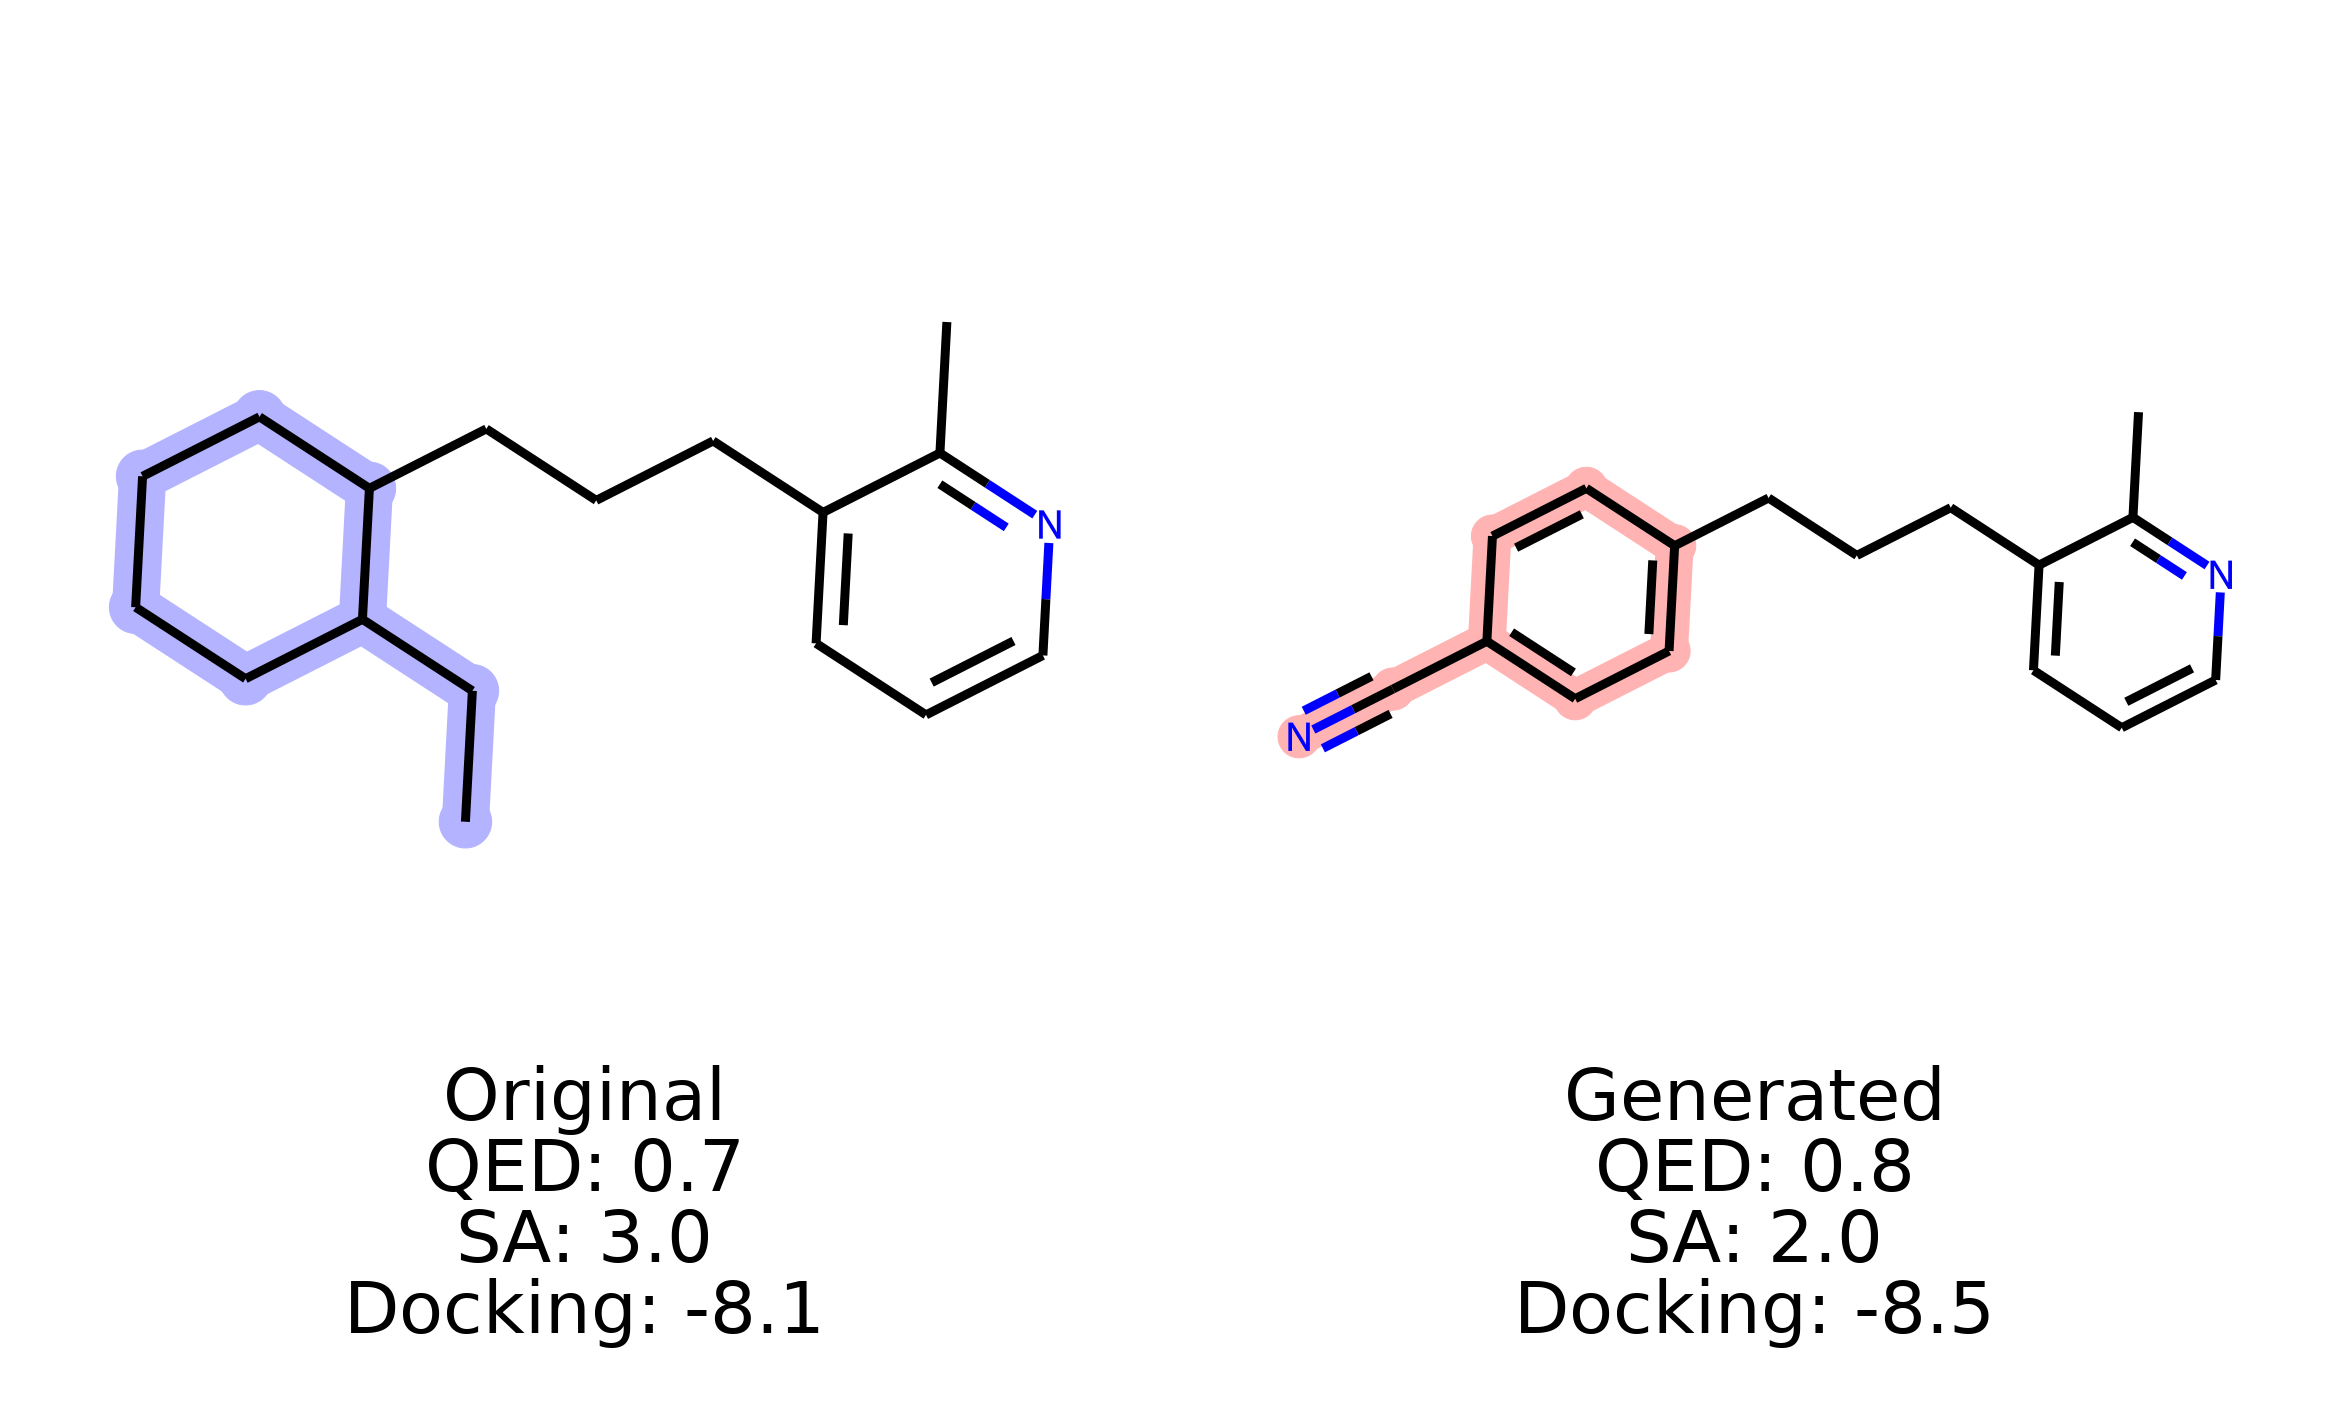

In [ ]:
row = df.iloc[1]
img = draw_mols(
    original_smi=row["INPUT-MOL-SMI"],
    generated_smi=row["GEN-MOL-SMI"],
    original_sa=row["SA"] - row["SA_DIFF"],
    original_qed=row["QED"] - row["QED_DIFF"],
    original_docking=row["INPUT-MOL-DOCKED-SCORE"],
    generated_sa=row["SA"],
    generated_qed=row["QED"],
    generated_docking=row["GEN-MOL-DOCKED-SCORE"],
    leaving_frag_smi=row["LEAVING-FRAG-SMI"],
    inserting_frag_smi=row["INSERTING-FRAG-SMI"],
    scale=3,
)
img